[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/03b_turbo.ipynb)

# 03b - TuRBO on the weighted KPI score

**Purpose.** Search the 36-dimensional tilt space with TuRBO-1 on the weighted
KPI score, and report one configuration to deploy.

**Inputs.** The committed cell table in `configs/simulation.yaml`, the scenario
manifest, `data/processed/mdt.parquet` for the served ratio, and the
weights in `configs/kpi.yaml`.

**Outputs.** `outputs/optim/turbo/<timestamp>/` - the evaluation history, the
published shortlist, the tilt table, the winner's radio map, and a run document.

---

### What this is, and is not

TuRBO-1 (Eriksson et al., 2019): one trust region centred on the best point, a
Gaussian process on the score, Thompson sampling within the region, and a
restart when the region collapses. The model sees one number per evaluation,
`scores` in `src/optim/objective.py` - the weighted sum of the four KPIs, signed
so larger is better - recorded in
[ADR 0003](../docs/adr/0003-turbo-on-a-weighted-kpi-score.md).

All four KPIs are still measured and published, and the `optim.n_solutions`
shortlist is built from them as for every method. The KPI
definitions come from
[ADR 0001](../docs/adr/0001-four-kpis-and-weighted-score.md) and live
only in `src/kpi/`.

**Baselines live in `03a_baseline.ipynb`.** Run that one too - a TuRBO result
with nothing to compare it against says very little.


## 0. Environment

Run this section first, wherever you are.

**Locally** it walks up to the project root and makes it the working directory,
so the root-relative paths in the configs resolve the way they do for
`task bo` and the DVC pipeline. Nothing is installed.

**In Colab** it also clones the repository, puts it on `sys.path`, and installs
what Colab does not ship. Sionna-RT needs a CUDA GPU — select a GPU runtime
first, or every evaluation will fail.


In [1]:
# --- Environment bootstrap -------------------------------------------------
# Identical in every notebook in this project.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
BRANCH = "main"
SUBDIR = ""  # the project root is the repository root

# (import name, pip name). Colab ships numpy, pandas, pyarrow, matplotlib and
# seaborn; these are the ones it does not. sionna-rt needs a CUDA runtime, so
# select a GPU runtime before running this notebook.
COLAB_PACKAGES = [
    ("hydra", "hydra-core"),
    ("sionna.rt", "sionna-rt"),
    ("botorch", "botorch"),
]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    checkout = Path("/content") / Path(REPO_URL).stem
    if not checkout.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(checkout)],
            check=True,
        )
    root = checkout / SUBDIR if SUBDIR else checkout
    missing = [pip for mod, pip in COLAB_PACKAGES if importlib.util.find_spec(mod) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    # JupyterLab starts the kernel in notebooks/; walk up to the project root.
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))  # makes `import src` work without an editable install

# Extra Hydra overrides consumed by load_config() in section 1. Reading them
# from the environment lets a smoke run shrink the budget, or a Colab session
# repoint the paths, without editing the notebook.
CONFIG_OVERRIDES: list[str] = os.environ.get("BAND_TILT_OVERRIDES", "").split()

print(f"project root: {root}   colab: {IN_COLAB}")

project root: D:\Projects\band-tilt   colab: False


In [2]:
# --- Colab: data and artifacts (optional) ----------------------------------
# data/ is DVC-tracked and not part of the clone, so a fresh Colab runtime has
# no scenario to optimize against. Either run notebook 00 first, or mount Drive
# and point the config at a copy that already holds one. Drive also survives a
# runtime reset, which /content does not.
#
# from google.colab import drive
#
# drive.mount("/content/drive")
# PROJECT_ROOT = "/content/drive/MyDrive/band-tilt"
# CONFIG_OVERRIDES += [
#     f"simulation.output.manifest_file={PROJECT_ROOT}/data/external/scenario.json",
#     f"data.output.mdt_file={PROJECT_ROOT}/data/processed/mdt.parquet",
#     f"optim.output.dir={PROJECT_ROOT}/outputs/optim",
# ]

## 1. Setup

In [3]:
# Standard setup for every notebook in this project.
# Autoreload so edits in src/ take effect without restarting the kernel.
%load_ext autoreload
%autoreload 2

from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.evaluation.export import save_table
from src.utils.plotting import save_fig, setup_plotting
from src.utils.seed import set_seed


cfg = load_config(overrides=["optim/method=turbo", *CONFIG_OVERRIDES])
set_seed(cfg.seed)
setup_plotting()

# Figures and tables land under reports/ so they can be looked at again without
# rerunning the search. Skipped on Colab, where /content does not survive a reset.
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/03b_turbo"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/03b_turbo"))

pd.set_option("display.max_columns", 60)
budget = cfg.optim.method.budget
print(f"method={cfg.optim.method.name}  seed={cfg.optim.seed}")
print(f"budget: n_init={budget.n_init} n_iter={budget.n_iter} batch={budget.batch_size}")

method=turbo  seed=42
budget: n_init=16 n_iter=128 batch=3


## 2. The search space

One absolute tilt per **(cell, band)** pair. The bounds are the committed ones
in `configs/simulation.yaml`; nothing here may widen them, and
`TiltSpace.to_cells` raises rather than ray-tracing a proposal that leaves the
box.


In [4]:
from src.optim.space import TiltSpace

space = TiltSpace.from_config(cfg)
print(f"{space.n_dim} decision variables: {len(space.cells)} cells x {len(space.band_names)} bands")

bounds = space.as_frame(space.baseline)
bounds.groupby("band", observed=True).agg(
    baseline=("tilt_deg", "first"),
    low=("tilt_min_deg", "first"),
    high=("tilt_max_deg", "first"),
    n_cells=("cell", "size"),
)

36 decision variables: 12 cells x 3 bands


,baseline,low,high,n_cells
band,,,,
b1800,9.0,0.0,10.0,12
b2600,10.0,0.0,10.0,12
b700,8.0,0.0,10.0,12


## 3. The incumbent

Everything is measured against the tilts currently committed in
`configs/simulation.yaml`. Evaluating them first is the reference row of every
comparison, the first point in TuRBO's data, and the check that this evaluator
agrees with the simulation stage - these KPIs must match the ones
`data/interim/radio_map.npz` scores to.


In [5]:
from src.kpi.capacity import max_rsrp
from src.optim.objective import KPI_NAMES
from src.optim.evaluator import Evaluator
from src.optim.report import publish


def kpi_table(named):
    """One column per configuration, one row per KPI, in priority order."""
    return pd.DataFrame({name: kpi.as_dict() for name, kpi in named.items()}).loc[list(KPI_NAMES)]

In [6]:
# Sionna-RT scores every candidate, so everything below is a measurement.
# Needs a GPU.
evaluator = Evaluator(cfg, keep_rsrp=True)
print(f"scenario {evaluator.scenario_id}   bands {evaluator.band_labels}")

incumbent = evaluator.evaluate(space.baseline)
print(f"one evaluation = {incumbent.seconds:.1f} s\n")
kpi_table({"incumbent": incumbent.kpi})

jitc_llvm_init(): LLVM API initialization failed ..


scenario scn_61e174bef723f9c4   bands ('b2600', 'b1800', 'b700')


one evaluation = 3.9 s



,incumbent
hole_rate,0.161844
overlap_rate,0.353077
served_ratio,0.775808
weak_rate,0.349109


## 4. The run

TuRBO spends `budget.n_init` Sobol points, then proposes `budget.batch_size`
points per round inside the trust region. A collapsed region restarts with a
fresh Sobol design out of the same budget. Random search in `03a_baseline.ipynb`
spends the same number of evaluations.

Ray tracing costs several seconds per candidate; the GP fit and Thompson
sampling per round are printed below as "model" so you can see which half you
are paying for.


In [7]:
import time

from src.optim.methods import run_search

started = time.time()
history = run_search(evaluator, cfg)
wall_clock = time.time() - started

frame = history.frame()
traced = frame["seconds"].sum()
print(f"{len(history)} candidates measured in {wall_clock / 60:.1f} min")
print(f"  ray tracing {traced / 60:.1f} min ({traced / wall_clock:.0%})")
print(f"  model       {(wall_clock - traced) / 60:.1f} min")
frame["phase"].value_counts()

145 candidates measured in 13.5 min
  ray tracing 10.0 min (74%)
  model       3.6 min


phase
search       128
init          16
incumbent      1
Name: count, dtype: int64

## 5. Progress

The best weighted score seen so far, the one number TuRBO maximises, beside each
KPI's best so far relative to the incumbent.


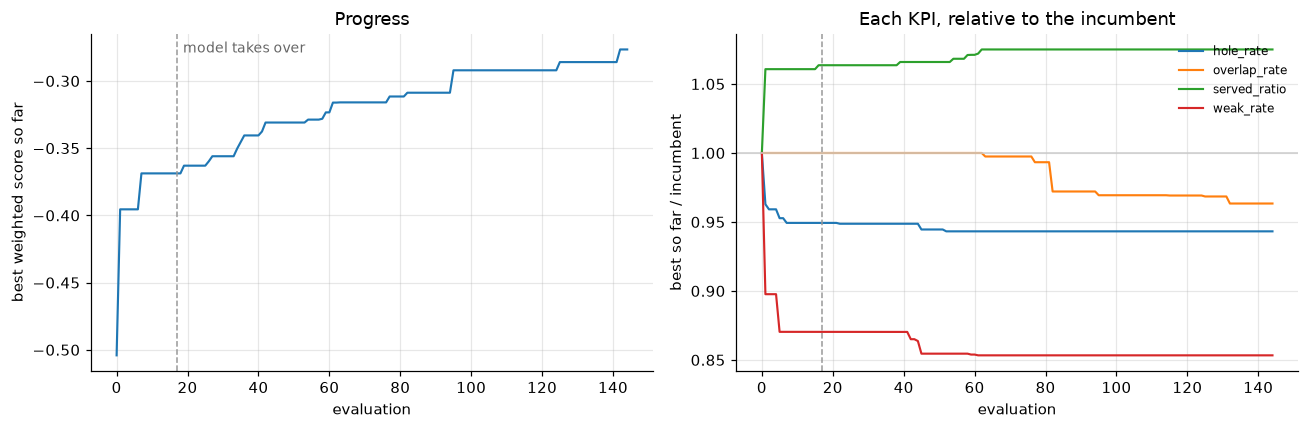

In [8]:
from src.optim.objective import scores

best_score = np.maximum.accumulate(scores(history.kpis, cfg))
switch = frame.index[frame["phase"] == "search"].min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(best_score, lw=1.4)
axes[0].axvline(switch, color="0.6", ls="--", lw=1)
axes[0].annotate(
    "model takes over",
    (switch, axes[0].get_ylim()[1]),
    xytext=(4, -12),
    textcoords="offset points",
    fontsize=9,
    color="0.4",
)
axes[0].set(xlabel="evaluation", ylabel="best weighted score so far", title="Progress")

# Best-so-far per KPI, each in its own direction. Three fall, one rises.
for name in KPI_NAMES:
    series = frame[name]
    running = series.cummax() if name == "served_ratio" else series.cummin()
    axes[1].plot(running / abs(series.iloc[0]), label=name, lw=1.4)
axes[1].axvline(switch, color="0.6", ls="--", lw=1)
axes[1].axhline(1.0, color="0.8", lw=1)
axes[1].set(
    xlabel="evaluation",
    ylabel="best so far / incumbent",
    title="Each KPI, relative to the incumbent",
)
axes[1].legend(fontsize=8)
fig.tight_layout()
save_fig(fig, "progress")

## 6. Choosing one configuration

The deliverable is one tilt table. The highest weighted score over
every evaluation picks it, with `kpi.weights` from `configs/kpi.yaml`; a tie
keeps the earlier row, so the incumbent holds unless beaten. `kpi.tolerance`
only labels each KPI's change as better, worse or a tie.


In [9]:
best_index = history.best_index(cfg)
best = history.results[best_index]

print(
    f"the weighted-score pick: evaluation {best_index} "
    f"(phase={frame.loc[best_index, 'phase']}, "
    f"node={frame.loc[best_index, 'generation_node']})\n"
)

comparison = kpi_table({"incumbent": incumbent.kpi, "best": best.kpi})
comparison["change"] = comparison["best"] - comparison["incumbent"]
comparison["direction"] = [
    "maximise" if n == "served_ratio" else "minimise" for n in comparison.index
]
save_table(comparison.rename_axis("kpi").reset_index(), "chosen_configuration")
comparison

the weighted-score pick: evaluation 142 (phase=search, node=TuRBO)



,incumbent,best,change,direction
hole_rate,0.161844,0.154849,-0.006996,minimise
overlap_rate,0.353077,0.340689,-0.012389,minimise
served_ratio,0.775808,0.833518,0.057710,maximise
weak_rate,0.349109,0.302127,-0.046982,minimise


### How far each antenna moved

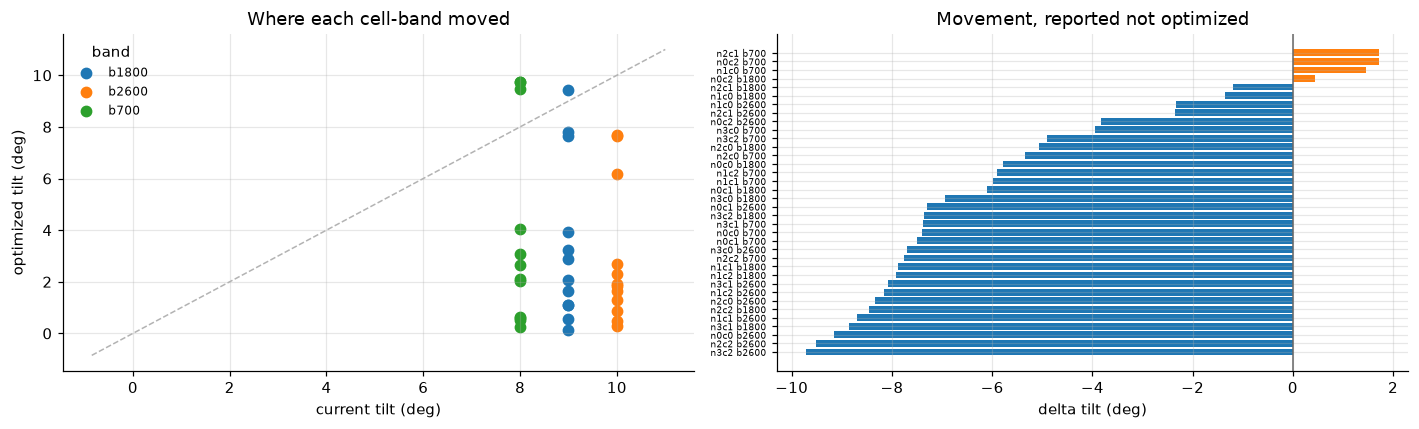

In [10]:
table = history.tilt_table(best.tilt_deg)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for band, group in table.groupby("band", observed=True):
    axes[0].scatter(group["current_tilt_deg"], group["optimized_tilt_deg"], label=band, s=45)
limits = [
    table[["current_tilt_deg", "optimized_tilt_deg"]].to_numpy().min() - 1,
    table[["current_tilt_deg", "optimized_tilt_deg"]].to_numpy().max() + 1,
]
axes[0].plot(limits, limits, color="0.7", ls="--", lw=1)
axes[0].set(
    xlabel="current tilt (deg)", ylabel="optimized tilt (deg)", title="Where each cell-band moved"
)
axes[0].legend(fontsize=8, title="band")

order = table.sort_values("delta_tilt_deg")
axes[1].barh(
    range(len(order)),
    order["delta_tilt_deg"],
    color=["tab:blue" if d < 0 else "tab:orange" for d in order["delta_tilt_deg"]],
)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order["cell"] + " " + order["band"], fontsize=6)
axes[1].axvline(0, color="0.4", lw=1)
axes[1].set(xlabel="delta tilt (deg)", title="Movement, reported not optimized")
fig.tight_layout()

table.sort_values("delta_tilt_deg", key=abs, ascending=False).head(10)
save_fig(fig, "tilt_movement")

### Coverage, before and after

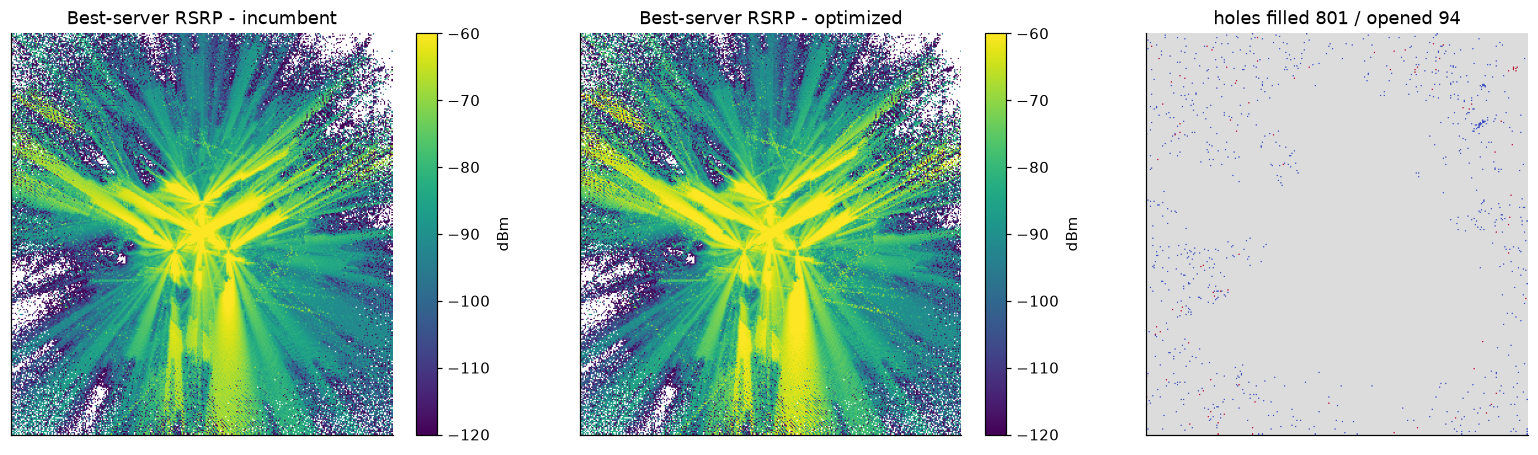

In [11]:
# Re-solved so the map is in hand for the panels below; the KPIs above already
# came from the ray tracer.
optimized = evaluator.evaluate(best.tilt_deg)

before = max_rsrp(incumbent.rsrp)
after = max_rsrp(optimized.rsrp)
hole_dbm = float(cfg.kpi.hole_dbm)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, data, title in ((axes[0], before, "incumbent"), (axes[1], after, "optimized")):
    im = ax.imshow(data, origin="lower", vmin=-120, vmax=-60, cmap="viridis")
    ax.set(title=f"Best-server RSRP - {title}", xticks=[], yticks=[])
    fig.colorbar(im, ax=ax, label="dBm", fraction=0.046)

# Where coverage changed state, which the RSRP panels alone do not show.
opened = (before > hole_dbm) & (after <= hole_dbm)
filled = (before <= hole_dbm) & (after > hole_dbm)
change = np.zeros_like(before)
change[filled] = 1
change[opened] = -1
axes[2].imshow(change, origin="lower", cmap="coolwarm_r", vmin=-1, vmax=1)
axes[2].set(title=f"holes filled {filled.sum()} / opened {opened.sum()}", xticks=[], yticks=[])
fig.tight_layout()
save_fig(fig, "coverage_before_after")

## 7. Persist

The same writer the CLI uses, so a notebook run and `task bo` leave byte-identical
artifacts. The directory is timestamped: comparing methods means comparing runs,
and a rerun must not overwrite the one it is compared against.


In [12]:
NOTEBOOK = "03b_turbo.ipynb"

In [13]:
from src.optim.run import output_directory

method = str(cfg.optim.method.name)
directory = output_directory(cfg, method)

written = publish(
    history,
    cfg,
    directory,
    method,
    extra={"scenario_id": evaluator.scenario_id, "notebook": NOTEBOOK},
)


turbo: 8 solutions published

 solution  recommended   score  hole_rate  overlap_rate  served_ratio  weak_rate
        0        False -0.5041     0.1618        0.3531        0.7758     0.3491
        1         True -0.2766     0.1548        0.3407        0.8335     0.3021
        2        False -0.2859     0.1549        0.3419        0.8311     0.3029
        3        False -0.2889     0.1551        0.3401        0.8287     0.3053
        4        False -0.2892     0.1548        0.3432        0.8309     0.3020
        5        False -0.2915     0.1539        0.3467        0.8326     0.3011
        6        False -0.2921     0.1545        0.3423        0.8280     0.3034
        7        False -0.2940     0.1550        0.3414        0.8274     0.3046

wrote outputs\optim\turbo\2026-09-15_11-49-57
  history: outputs\optim\turbo\2026-09-15_11-49-57\history.parquet
  best_tilt: outputs\optim\turbo\2026-09-15_11-49-57\best_tilt.parquet
  run: outputs\optim\turbo\2026-09-15_11-49-57\run.json

## 8. Handoff checklist

- [ ] The incumbent's KPIs matched `data/interim/radio_map.npz`
- [ ] Every evaluated tilt stayed inside the committed bounds
- [ ] The four KPIs came from `src/kpi/`, with no threshold restated here
- [ ] The winner is the highest weighted score, with the weights in `configs/kpi.yaml`
- [ ] `03a_baseline.ipynb` has been run, so there is something to compare against
- [ ] The run directory holds history, solutions, best_tilt, best_radio_map and run.json
